In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
data = pd.read_csv('gaia_stars_with_phases.csv')
print(f"Dataset contains {len(data)} stars")
print("\nAvailable columns:", data.columns.tolist())

Dataset contains 70118 stars

Available columns: ['ra', 'dec', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'radial_velocity', 'ruwe', 'teff_gspphot', 'phot_variable_flag', 'distance_pc', 'abs_mag', 'phase', 'cluster']


In [3]:
# Prepare feature matrix
features = data[['bp_rp', 'abs_mag', 'teff_gspphot']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

Silhouette

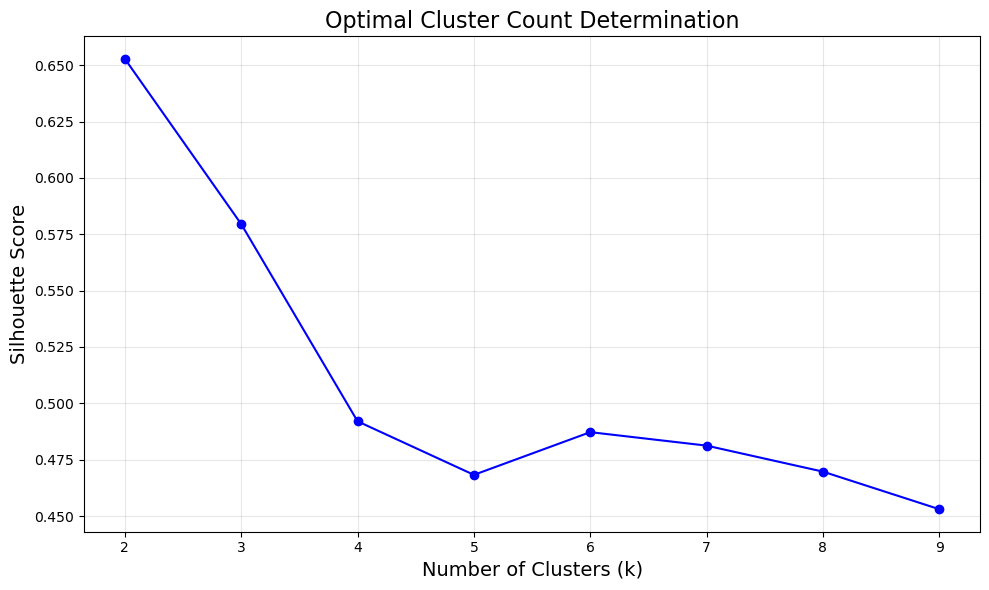

Optimal cluster count: 2


In [4]:
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Optimal Cluster Count Determination', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal cluster count: {k_range[np.argmax(silhouette_scores)]}")

GMM

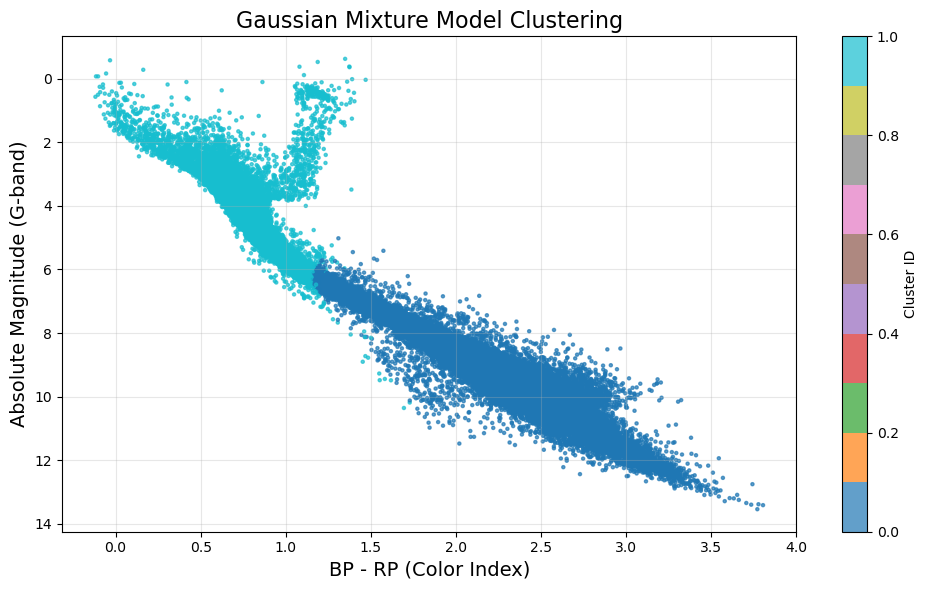


GMM Cluster Characteristics:


,gmm_cluster,bp_rp,abs_mag,teff_gspphot,phase
0,0,2.114170,8.864128,3819.312475,Main Sequence
1,1,0.843892,4.578499,5707.981478,Main Sequence


In [5]:
n_components = k_range[np.argmax(silhouette_scores)]
gmm = GaussianMixture(n_components=n_components, random_state=42)
data['gmm_cluster'] = gmm.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['gmm_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Gaussian Mixture Model Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze cluster properties
gmm_cluster_stats = data.groupby('gmm_cluster').agg({
    'bp_rp': 'mean',
    'abs_mag': 'mean',
    'teff_gspphot': 'mean',
    'phase': lambda x: x.value_counts().index[0]  # Most common phase
}).reset_index()
print("\nGMM Cluster Characteristics:")
display(gmm_cluster_stats)

DBSCAN

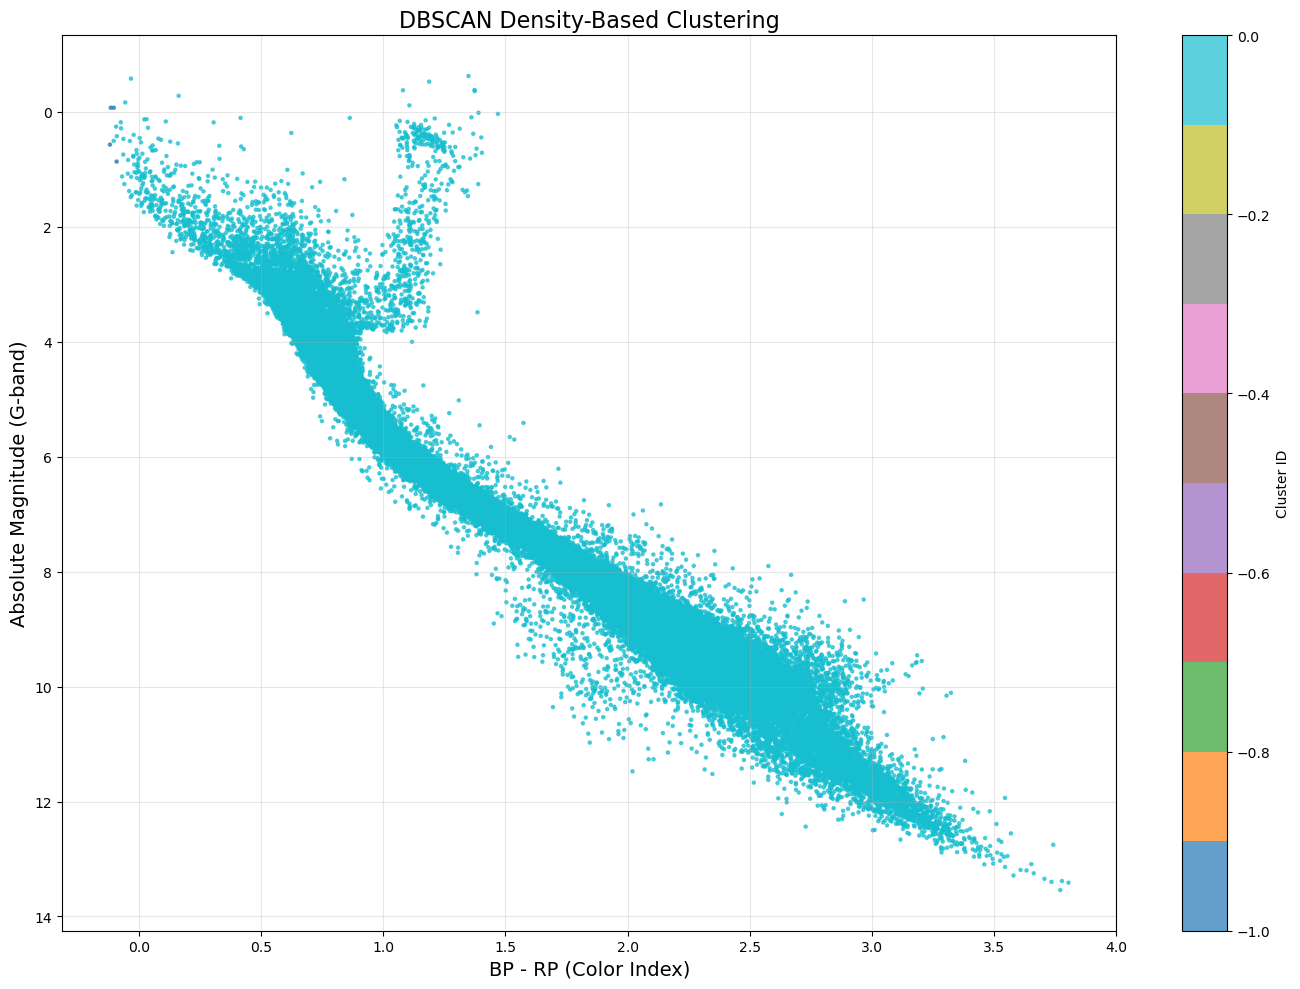


DBSCAN Cluster Distribution:
dbscan_cluster
 0    70114
-1        4
Name: count, dtype: int64


In [6]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
data['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(14, 10))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['dbscan_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('DBSCAN Density-Based Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze cluster distribution
dbscan_counts = data['dbscan_cluster'].value_counts()
print("\nDBSCAN Cluster Distribution:")
print(dbscan_counts)

In [7]:
# Define clustering methods
methods = ['phase', 'cluster', 'gmm_cluster', 'dbscan_cluster']

# Create a new comparison dataframe with only existing columns
comparison = data[methods + ['bp_rp', 'abs_mag']].copy()

phase_mapping = {
    0: 'Main Sequence',
    1: 'Giants',
    2: 'White Dwarfs',
    3: 'Subgiants',
    4: 'Supergiants'
}

# Generate phase labels for each clustering method
for method in methods[1:]:
    # Map cluster ID to most common phase
    cluster_map = {}
    for cluster_id in data[method].unique():
        if cluster_id == -1:
            cluster_map[cluster_id] = 'Noise'  # DBSCAN noise label
        else:
            cluster_map[cluster_id] = data[data[method] == cluster_id]['phase'].mode()[0]
    
    # Assign new column with mapped phase names
    comparison[f'{method}_phase'] = comparison[method].map(cluster_map)


# Calculate agreement with rule-based phases
for method in methods[1:]:
    agreement = np.mean(comparison['phase'] == comparison[f'{method}_phase'])
    print(f"Agreement between rule-based and {method}: {agreement:.2%}")

Agreement between rule-based and cluster: 89.55%
Agreement between rule-based and gmm_cluster: 82.78%
Agreement between rule-based and dbscan_cluster: 82.78%


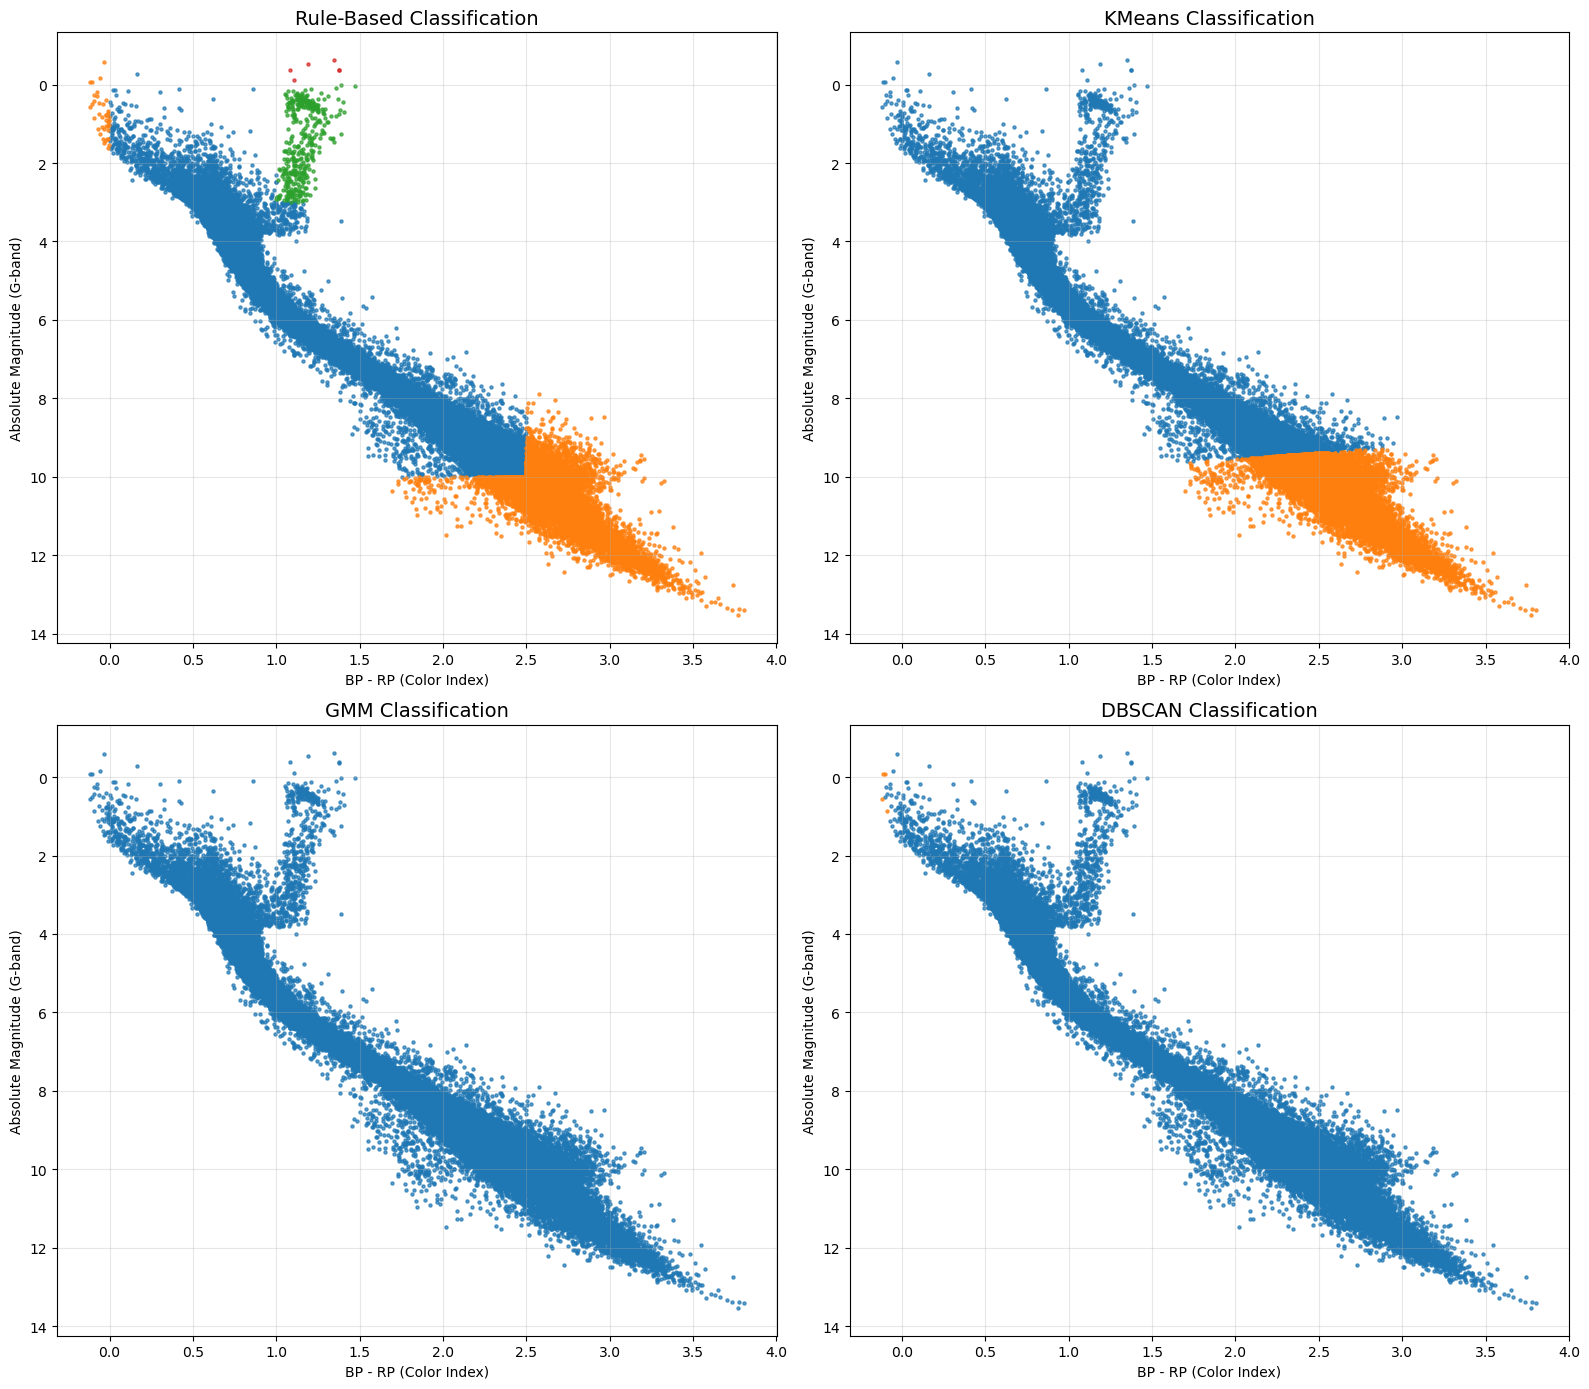

In [8]:
plot_methods = ['phase', 'cluster_phase', 'gmm_cluster_phase', 'dbscan_cluster_phase']
titles = [
    'Rule-Based Classification',
    'KMeans Classification',
    'GMM Classification',
    'DBSCAN Classification'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, method, title in zip(axes.flatten(), plot_methods, titles):
    for label in comparison[method].unique():
        subset = comparison[comparison[method] == label]
        ax.scatter(
            subset['bp_rp'],
            subset['abs_mag'],
            s=5,
            alpha=0.7,
            label=label
        )
    ax.invert_yaxis()
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('BP - RP (Color Index)')
    ax.set_ylabel('Absolute Magnitude (G-band)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Mapping from cluster ID to stellar evolutionary phase
phase_mapping = {
    0: 'Main Sequence',
    1: 'Giants',
    2: 'White Dwarfs',
    3: 'Subgiants',
    4: 'Supergiants'
}

# Create a new column with mapped phase names
data['final_phase'] = data['cluster'].map(phase_mapping)
print(data['final_phase'].value_counts())

final_phase
Supergiants      18040
Main Sequence    16955
White Dwarfs     13799
Giants           13556
Subgiants         7768
Name: count, dtype: int64


In [ ]:
# Phase-Specific Analysis
# Define final phase based on rule-based classification
data['final_phase'] = data['cluster'].map(phase_mapping)  

# Main Sequence Analysis
main_sequence = data[data['final_phase'] == "Main Sequence"]
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='bp_rp', 
    y='abs_mag', 
    hue='teff_gspphot', 
    data=main_sequence, 
    palette='viridis_r',
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.title('Main Sequence Stars', fontsize=16)
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
